# Forward and backward propagation from scratch (NumPy only)

**Goal:** build a small neural network by hand, with no Keras or TensorFlow, and train it with backpropagation.

- **Data:** 2 features, 1 target (exam score)
- **Hidden activation:** linear (we change this later)
- **Output activation:** linear
- **Loss:** squared error of one row, `L = (y - ŷ)²`
- **Training:** update the weights after every row (stochastic gradient descent), as in the notes

We build two networks with the same code:

| Network | Layer sizes | Parameters |
|---|---|---|
| Single hidden layer | `[2, 2, 1]` | 9 |
| Two hidden layers | `[2, 2, 2, 1]` | 15 |

## 1. Dataset

Columns: `hours_studied`, `hours_slept`. The target follows a hidden rule with no noise:

`exam_score = 10 + 10 * hours_studied + 5 * hours_slept`

Because the rule is exact, a correct network must reach a loss of about 0. If it does not, there is a bug.

In [1]:
import numpy as np

# columns: [hours_studied, hours_slept]
X = np.array([[2, 6],
              [3, 7],
              [4, 5],
              [1, 8]], dtype=float)

y = np.array([60, 75, 75, 60], dtype=float)

print("X shape:", X.shape)   # (4, 2)
print("y shape:", y.shape)   # (4,)

X shape: (4, 2)
y shape: (4,)


## 2. Activation function (hidden layers only)

The output layer is always linear, so only the hidden layers use these two functions.

- `act(z)` is the activation `a = f(z)`
- `act_grad(z)` is its derivative `da/dz`

With a linear activation, `a = z` and `da/dz = 1`. To make the network non-linear later, **change only these two functions**. For example, for tanh:

```python
def act(z):      return np.tanh(z)
def act_grad(z): return 1 - np.tanh(z) ** 2
```

In [2]:
def act(z):
    return z                      # linear: a = z


def act_grad(z):
    return np.ones_like(z)        # linear: da/dz = 1

## 3. Loss function

For one row: `L = (y - ŷ)²`

Its derivative with respect to the prediction is the first link of every chain rule:

`dL/dŷ = -2 (y - ŷ)`

The `-1` comes from differentiating `(y - ŷ)` with respect to `ŷ`.

In [ ]:
def loss_one_row(target, y_hat):
    """L = (y - y_hat)^2 for one row."""
    return ((target - y_hat) ** 2).item() # .item() returns a plain float

## 4. The network

Shapes used everywhere (row-vector convention, `x @ W`):

- `W[l]` has shape `(nodes_in, nodes_out)`. **Column j holds the weights going into node j.**
- `b[l]` has one bias per node of layer `l`, shape `(nodes_out,)`.

**Forward propagation** (for each layer `l`):

```
z[l]   = a[l] @ W[l] + b[l]
a[l+1] = act(z[l])      for hidden layers
a[l+1] = z[l]           for the output layer (linear)
```

**Backpropagation** goes from the output back to the input. For each layer:

```
dz         = dL/da * da/dz          (da/dz = 1 at the linear output)
dW         = a_prev^T * dz          (a_prev = the input to this layer)
db         = dz
dL/da_prev = dz @ W^T               (sent back to the previous layer)
```

**Update** (gradient descent): `w = w - lr * dL/dw` and `b = b - lr * dL/db`.

Weights start as small random numbers. If they all started equal (for example all 1), the nodes of a layer would get identical gradients and stay identical forever.

In [4]:
class ANN:
    def __init__(self, layer_sizes, lr, seed=42):
        """
        layer_sizes : e.g. [2, 2, 1] = 2 inputs, 2 hidden nodes, 1 output
        lr          : learning rate (eta)
        """
        rng = np.random.default_rng(seed)
        self.lr = lr
        self.n_layers = len(layer_sizes) - 1          # layers that have weights

        self.W = [rng.normal(0, 0.5, size=(n_in, n_out))
                  for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:])]
        self.b = [np.zeros(n_out) for n_out in layer_sizes[1:]]

    # ---------------- forward propagation ----------------
    def forward(self, x):
        """x: one row, shape (n_features,). Saves every z and a for backprop."""
        self.a = [x]
        self.z = []
        for l in range(self.n_layers):
            z = self.a[l] @ self.W[l] + self.b[l]
            is_output = (l == self.n_layers - 1)
            a = z if is_output else act(z)
            self.z.append(z)
            self.a.append(a)
        return self.a[-1]                              # y_hat, shape (1,)

    # ---------------- backpropagation ----------------
    def backward(self, target):
        """Call forward() on the same row first. Returns dW and db for every layer."""
        y_hat = self.a[-1]
        dL_da = -2 * (target - y_hat)                  # dL/dy_hat

        dW = [None] * self.n_layers
        db = [None] * self.n_layers

        for l in reversed(range(self.n_layers)):
            is_output = (l == self.n_layers - 1)
            if is_output:
                dz = dL_da                             # output is linear: da/dz = 1
            else:
                dz = dL_da * act_grad(self.z[l])       # times da/dz of this layer

            dW[l] = np.outer(self.a[l], dz)            # (nodes_in, nodes_out)
            db[l] = dz                                 # (nodes_out,)
            dL_da = dz @ self.W[l].T                   # pass back (uses the OLD W)

        return dW, db

    # ---------------- parameter update ----------------
    def update(self, dW, db):
        for l in range(self.n_layers):
            self.W[l] -= self.lr * dW[l]               # w = w - eta * dL/dw
            self.b[l] -= self.lr * db[l]               # b = b - eta * dL/db

    def predict(self, X):
        return np.array([self.forward(x).item() for x in X])

    def collapse(self):
        """With linear activations all layers merge into ONE line:
        y_hat = x @ W_eff + b_eff  (valid only while act is linear)."""
        W_eff, b_eff = self.W[0], self.b[0]
        for l in range(1, self.n_layers):
            b_eff = b_eff @ self.W[l] + self.b[l]
            W_eff = W_eff @ self.W[l]
        return W_eff.ravel(), b_eff.item()

## 5. Forward prop on row 1, with the fixed numbers from our hand calculation

Before using random weights, we put in the same numbers we used by hand, to check that the code matches.

Row 1: `x = [2, 6]`, true score 60. Expected: `z1 = [1.5, 3.1]` and `ŷ = 2.71`.

In [5]:
net = ANN([2, 2, 1], lr=0.0005)

# overwrite the random weights with the hand-calculation numbers
net.W[0] = np.array([[0.1, 0.3],
                     [0.2, 0.4]])
net.b[0] = np.array([0.1, 0.1])
net.W[1] = np.array([[0.5],
                     [0.6]])
net.b[1] = np.array([0.1])

y_hat = net.forward(X[0])
print("z1    :", net.z[0])        # [1.5 3.1]
print("y_hat :", y_hat)           # [2.71]
print("loss  :", loss_one_row(y[0], y_hat))          # 3282.1441
print("dL/dy_hat:", -2 * (y[0] - y_hat))             # [-114.58]

z1    : [1.5 3.1]
y_hat : [2.71]
loss  : 3282.1441
dL/dy_hat: [-114.58]


### Backprop on the same row

Now the derivatives for all 9 parameters. By hand, with `dL/dŷ = -114.58`:

- Output layer: `dW2 = a1ᵀ · dL/dŷ = [1.5, 3.1] × -114.58` and `db2 = -114.58`
- Hidden layer: the error sent back is `dL/da1 = dL/dŷ × W2ᵀ = -114.58 × [0.5, 0.6]`, then `dW1 = xᵀ · dL/da1`

In [6]:
dW, db = net.backward(y[0])

print("dW2 (output weights):\n", dW[1])     # [[-171.87], [-355.198]]
print("db2 (output bias)   :", db[1])        # [-114.58]
print()
print("dW1 (hidden weights):\n", dW[0])
print("db1 (hidden biases) :", db[0])

dW2 (output weights):
 [[-171.87 ]
 [-355.198]]
db2 (output bias)   : [-114.58]

dW1 (hidden weights):
 [[-114.58  -137.496]
 [-343.74  -412.488]]
db1 (hidden biases) : [-57.29  -68.748]


## 6. Gradient check

How do we know `backward()` is correct? Compare it with a **numerical** derivative, which only needs `forward()`:

`dL/dw ≈ (L(w + ε) - L(w - ε)) / (2ε)`

If backprop is right, the relative error is tiny (around 1e-7 or smaller).

In [7]:
def gradient_check(net, x, target, eps=1e-5):
    net.forward(x)
    dW, db = net.backward(target)
    worst = 0.0

    def numeric(param, idx):
        old = param[idx]
        param[idx] = old + eps
        l_plus = loss_one_row(target, net.forward(x))
        param[idx] = old - eps
        l_minus = loss_one_row(target, net.forward(x))
        param[idx] = old
        return (l_plus - l_minus) / (2 * eps)

    for l in range(net.n_layers):
        for idx in np.ndindex(net.W[l].shape):
            num, ana = numeric(net.W[l], idx), dW[l][idx]
            worst = max(worst, abs(num - ana) / max(1e-8, abs(num) + abs(ana)))
        for idx in np.ndindex(net.b[l].shape):
            num, ana = numeric(net.b[l], idx), db[l][idx]
            worst = max(worst, abs(num - ana) / max(1e-8, abs(num) + abs(ana)))
    return worst


print("Max relative error:", gradient_check(net, X[0], y[0]))

Max relative error: 2.4040752715071e-10


## 7. Training loop

For every row, in every epoch:

1. forward propagation, to get `ŷ`
2. loss, to see how wrong it is
3. backpropagation, to get all the derivatives
4. update `w` and `b`

The printed `MSE` is the average of the 4 row losses in that epoch.

In [8]:
def train(net, X, y, epochs, print_every):
    history = []
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        for xi, target in zip(X, y):
            y_hat = net.forward(xi)                    # 1. forward prop
            total_loss += loss_one_row(target, y_hat)  # 2. loss
            dW, db = net.backward(target)              # 3. backprop
            net.update(dW, db)                         # 4. update w and b
        mse = total_loss / len(X)
        history.append(mse)
        if epoch == 1 or epoch % print_every == 0:
            print(f"  epoch {epoch:>6} | MSE = {mse:.6f}")
    return history


def run(name, layer_sizes, lr, epochs, print_every):
    print("=" * 60)
    print(f"{name}   layers = {layer_sizes}   lr = {lr}")
    print("=" * 60)

    net = ANN(layer_sizes, lr=lr, seed=42)

    err = gradient_check(net, X[0], y[0])
    print(f"Gradient check (max relative error): {err:.2e}")
    print(f"Row 1 prediction before training: {net.forward(X[0]).item():.4f} (true = {y[0]:.0f})")

    print("Training:")
    history = train(net, X, y, epochs, print_every)

    preds = net.predict(X)
    print("\nResults after training:")
    print("  x1  x2 | true | predicted")
    for xi, t, p in zip(X, y, preds):
        print(f"  {xi[0]:.0f}   {xi[1]:.0f}  | {t:>4.0f} | {p:>9.4f}")

    w_eff, b_eff = net.collapse()
    print(f"\nAll layers merged into one line: y = {b_eff:.3f} + {w_eff[0]:.3f}*x1 + {w_eff[1]:.3f}*x2")
    print("True rule:                       y = 10 + 10*x1 + 5*x2\n")
    return net, history

## 8. Network 1: one hidden layer `[2, 2, 1]`

2 inputs, 2 hidden nodes, 1 output node. 4 + 2 weights/biases in the hidden layer and 2 + 1 in the output, so 9 parameters.

In [9]:
net1, hist1 = run("SINGLE HIDDEN LAYER ANN", [2, 2, 1], lr=0.0005, epochs=20000, print_every=2000)

SINGLE HIDDEN LAYER ANN   layers = [2, 2, 1]   lr = 0.0005
Gradient check (max relative error): 2.26e-10
Row 1 prediction before training: -3.6535 (true = 60)
Training:
  epoch      1 | MSE = 4313.798889


  epoch   2000 | MSE = 0.177645


  epoch   4000 | MSE = 0.023127


  epoch   6000 | MSE = 0.002607


  epoch   8000 | MSE = 0.000276


...

  epoch  12000 | MSE = 0.000003


  epoch  14000 | MSE = 0.000000


  epoch  16000 | MSE = 0.000000


  epoch  18000 | MSE = 0.000000


  epoch  20000 | MSE = 0.000000

Results after training:
  x1  x2 | true | predicted
  2   6  |   60 |   60.0000
  3   7  |   75 |   75.0000
  4   5  |   75 |   75.0000
  1   8  |   60 |   60.0000

All layers merged into one line: y = 10.000 + 10.000*x1 + 5.000*x2
True rule:                       y = 10 + 10*x1 + 5*x2



## 9. Network 2: two hidden layers `[2, 2, 2, 1]`

Same code, one more hidden layer. The learning rate is smaller (`0.0002`) because deeper networks have larger gradients.

In [10]:
net2, hist2 = run("TWO HIDDEN LAYER ANN", [2, 2, 2, 1], lr=0.0002, epochs=20000, print_every=2000)

TWO HIDDEN LAYER ANN   layers = [2, 2, 2, 1]   lr = 0.0002
Gradient check (max relative error): 1.11e-08
Row 1 prediction before training: 0.8500 (true = 60)
Training:
  epoch      1 | MSE = 4340.657347


  epoch   2000 | MSE = 0.291789


  epoch   4000 | MSE = 0.043782


  epoch   6000 | MSE = 0.005830
  epoch   8000 | MSE = 0.000730


  epoch  10000 | MSE = 0.000089


  epoch  12000 | MSE = 0.000011


  epoch  14000 | MSE = 0.000001


  epoch  16000 | MSE = 0.000000


  epoch  18000 | MSE = 0.000000


  epoch  20000 | MSE = 0.000000

Results after training:
  x1  x2 | true | predicted
  2   6  |   60 |   60.0000
  3   7  |   75 |   75.0001
  4   5  |   75 |   75.0001
  1   8  |   60 |   60.0000

All layers merged into one line: y = 10.000 + 10.000*x1 + 5.000*x2
True rule:                       y = 10 + 10*x1 + 5*x2



## 10. Loss curves

The loss is drawn on a log scale, because it falls from thousands to nearly 0.

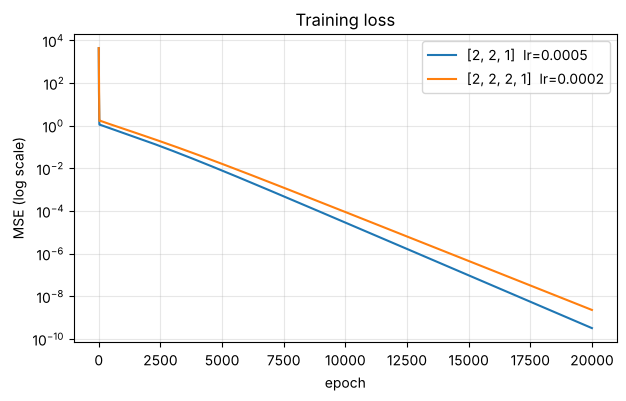

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(hist1, label="[2, 2, 1]  lr=0.0005")
plt.plot(hist2, label="[2, 2, 2, 1]  lr=0.0002")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE (log scale)")
plt.title("Training loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11. Why the learning rates are so small

The inputs (1 to 8) and targets (60 to 75) are not scaled, so the gradients are large. If the learning rate is too big, each update jumps past the minimum, the loss grows, and it ends in `nan` (overflow).

Run the cell below to see it. Then try changing `lr` back to `0.0005`.

In [12]:
import warnings
warnings.filterwarnings("ignore")

bad = ANN([2, 2, 1], lr=0.005, seed=42)
for epoch in range(1, 9):
    total = 0.0
    for xi, t in zip(X, y):
        total += loss_one_row(t, bad.forward(xi))
        dW, db = bad.backward(t)
        bad.update(dW, db)
    print(f"epoch {epoch} | MSE = {total / len(X):.3e}")

epoch 1 | MSE = 8.961e+09
epoch 2 | MSE = inf
epoch 3 | MSE = nan
epoch 4 | MSE = nan
epoch 5 | MSE = nan
epoch 6 | MSE = nan
epoch 7 | MSE = nan
epoch 8 | MSE = nan


## 12. Next step: make it non-linear

With linear activations, the whole network collapses into one straight line, which is why section 8 and 9 end with the same rule `10 + 10·x1 + 5·x2`. That is also a good test that our code is right.

To add non-linearity, only change `act` and `act_grad` (section 2). In backprop, the factor `da/dz` stops being 1, so each hidden layer's `dz` is scaled by the slope of the activation. Everything else stays the same. We would also switch to a small non-linear dataset, so the activation has something to learn.